In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from tslearn.metrics import cdist_dtw
from helper_plots import plot_pseudotime_for_cells
from pathlib import Path

def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )


def compute_mean_std(ts_list):
    ts_list = [np.asarray(ts, dtype=float) for ts in ts_list]
    max_len = max(len(ts) for ts in ts_list)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), constant_values=np.nan)
        for ts in ts_list
    ]
    mat = np.vstack(aligned)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def plot_kmeans_mean_shapes(X, labels):
    plt.figure(figsize=(12,6))

    for lab in sorted(set(labels)):
        idx = np.where(labels == lab)[0]
        ts_list = [X[i] for i in idx]

        mean_ts, std_ts = compute_mean_std(ts_list)
        t = np.arange(len(mean_ts))

        plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
        plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.2)

    plt.title("KMeans Mean Shape per Cluster (± STD)")
    plt.legend()
    plt.show()

In [84]:

SD_clean = pd.read_pickle("datasets/pseudotime_cells_clean_1476.pkl")

n = 6  # minimum required length

SD_clean = SD_clean[SD_clean["pseudotime_widths"].apply(len) >= n]

outliers = []
with open(r"datasets\1476_dapi_python_segmentation_outliers.txt", "r") as f:
    for line in f:
        outliers.append(line.strip() +".tif")

print(outliers)

SD_clean = SD_clean[
    ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
]

X = SD_clean["pseudotime_widths"].to_list()

SD_clean

['obj6270001_stainDAPI.tif', 'obj6290001_stainDAPI.tif', 'obj6560001_stainDAPI.tif', 'obj6680001_stainDAPI.tif', 'obj6700001_stainDAPI.tif', 'obj6760006_stainDAPI.tif', 'obj6760006_stainDAPI.tif', 'obj6840001_stainDAPI.tif', 'obj7550001_stainDAPI.tif', 'obj7560001_stainDAPI.tif', 'obj7560005_stainDAPI.tif', 'obj7560056_stainDAPI.tif', 'obj7580001_stainDAPI.tif', 'obj7580003_stainDAPI.tif', 'obj8090003_stainDAPI.tif', 'obj8600002_stainDAPI.tif', 'obj2780002_stainDAPI.tif', 'obj2840002_stainDAPI.tif', 'obj2840005_stainDAPI.tif', 'obj2970002_stainDAPI.tif', 'obj3190001_stainDAPI.tif', 'obj3250002_stainDAPI.tif', 'obj3530001_stainDAPI.tif', 'obj3530002_stainDAPI.tif', 'obj3530003_stainDAPI.tif', 'obj3530004_stainDAPI.tif', 'obj3800002_stainDAPI.tif', 'obj3810001_stainDAPI.tif', 'obj3900002_stainDAPI.tif', 'obj4040002_stainDAPI.tif', 'obj4440001_stainDAPI.tif', 'obj4770001_stainDAPI.tif', 'obj4890002_stainDAPI.tif', 'obj5180002_stainDAPI.tif', 'obj6020001_stainDAPI.tif', 'obj50001_stainDAPI

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_min_x,centered_bbox_min_y,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.230345,3.731586,0.557365,...,-47.5,33.5,-37.5,45.5,-56.791968,21.514013,-44.271813,35.513279,"[5, 6, 6, 7, 7, 8, 0, 0]","[8, 7, 7, 8, 11, 9, 19, 16]"
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.537209,17.958140,0.057723,...,-60.5,5.5,-30.5,16.5,-62.679214,-8.743934,-30.942156,8.941564,"[4, 4, 5, 5, 6, 6, 7, 7, 8, 0, 0, 1, 1, 2, 2, ...","[2, 4, 6, 8, 7, 7, 8, 11, 10, 18, 16, 13, 11, ..."
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.104247,2.147490,0.461122,...,-57.5,31.5,-38.5,48.5,-67.215697,17.239667,-44.778433,38.197819,"[3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 0]","[8, 4, 3, 4, 6, 8, 7, 7, 8, 11, 9, 19]"
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.311155,11.326027,0.061208,...,72.5,-26.5,96.5,-15.5,74.116182,-8.883164,100.018289,7.404717,"[3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 0, 0, 1, 1]","[4, 4, 6, 7, 7, 7, 7, 9, 11, 10, 19, 15, 12, 11]"
50002,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.196970,5.278788,0.287822,...,-35.5,-79.5,-5.5,-55.5,-21.595508,-85.582351,13.169722,-55.254456,"[6, 6, 7, 7, 8, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, ...","[8, 9, 8, 10, 11, 21, 20, 17, 12, 12, 11, 11, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8570001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.421150,14.693465,0.409134,...,56.5,-23.5,79.5,3.5,54.130522,-9.692667,82.787116,21.922150,"[7, 8, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5]","[10, 12, 20, 19, 15, 13, 12, 12, 10, 5, 4, 4, ..."
8580001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.294118,10.470588,0.482305,...,-17.5,-44.5,8.5,-30.5,-9.914056,-47.352278,18.631843,-27.681049,"[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7]","[19, 17, 12, 12, 12, 11, 8, 5, 5, 4, 5, 7, 7, ..."
8590001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.364063,11.467969,0.069561,...,-8.5,-9.5,15.5,8.5,-10.246140,-11.218632,17.286520,11.876693,"[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]","[18, 15, 12, 12, 12, 12, 7, 5, 3, 5, 8, 8, 9, 7]"


In [85]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        # np.max(ts),
        # np.min(ts),
        len(ts)
    ]
    for ts in X
]

# #ignore class 3(grenn)
kmeans = KMeans(n_clusters=3, random_state=42)
# kmeans.fit(features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=3)
X_embedded = pca.fit_transform(X_scaled)

kmeans.fit(X_embedded)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


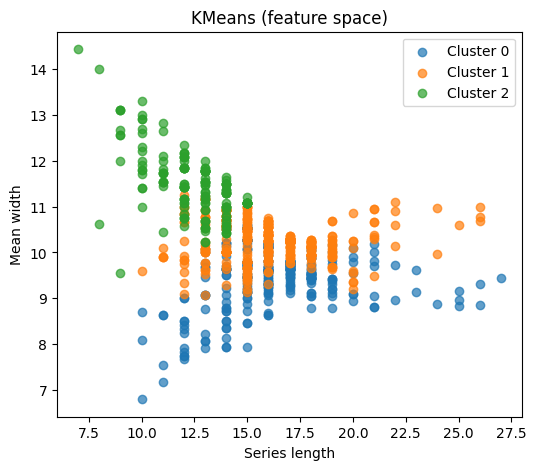

In [86]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

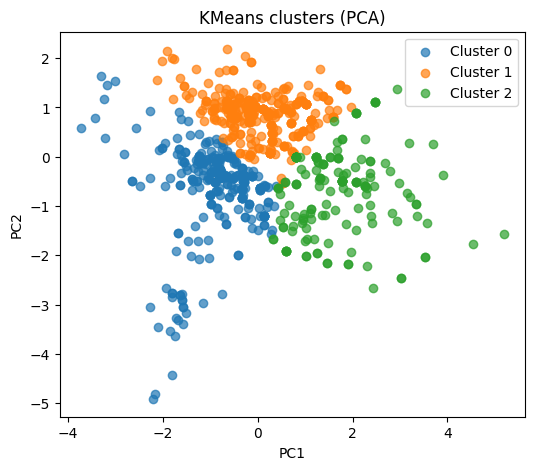

In [87]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

C:\Users\dmitr\AppData\Local\Temp\ipykernel_28536\1429122847.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj2860001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj7010002_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj7620001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj1970001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj2820001_stainDAPI.tif


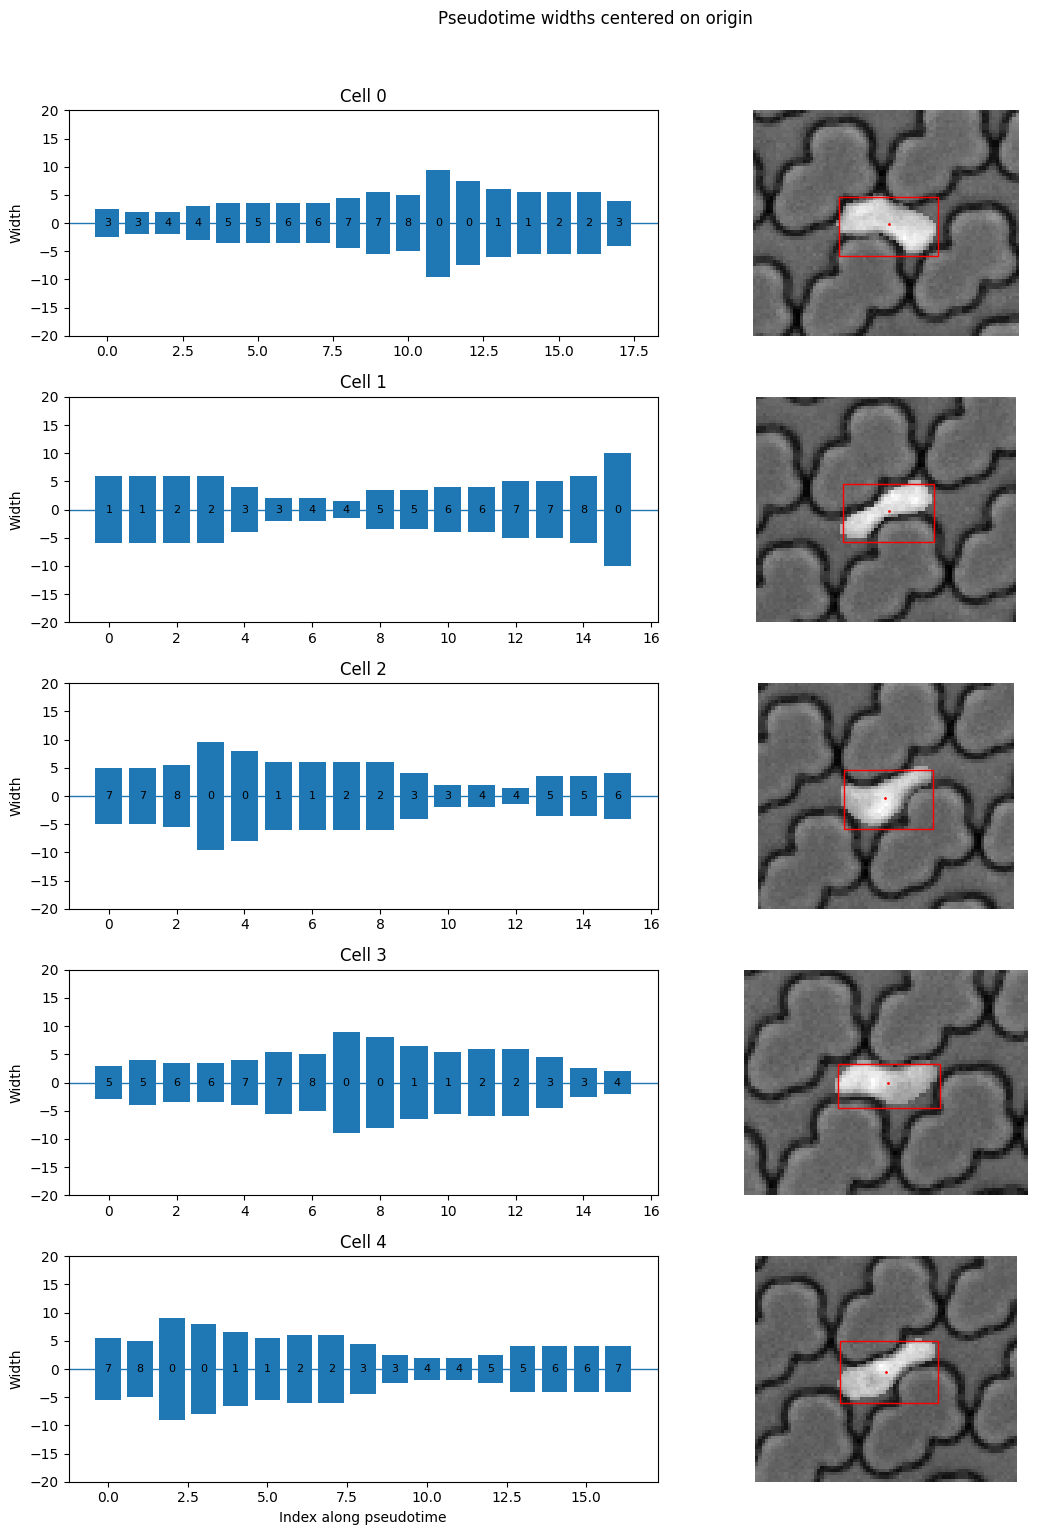

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj7530001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj1270001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj7410001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj6610001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj3430001_stainDAPI.tif


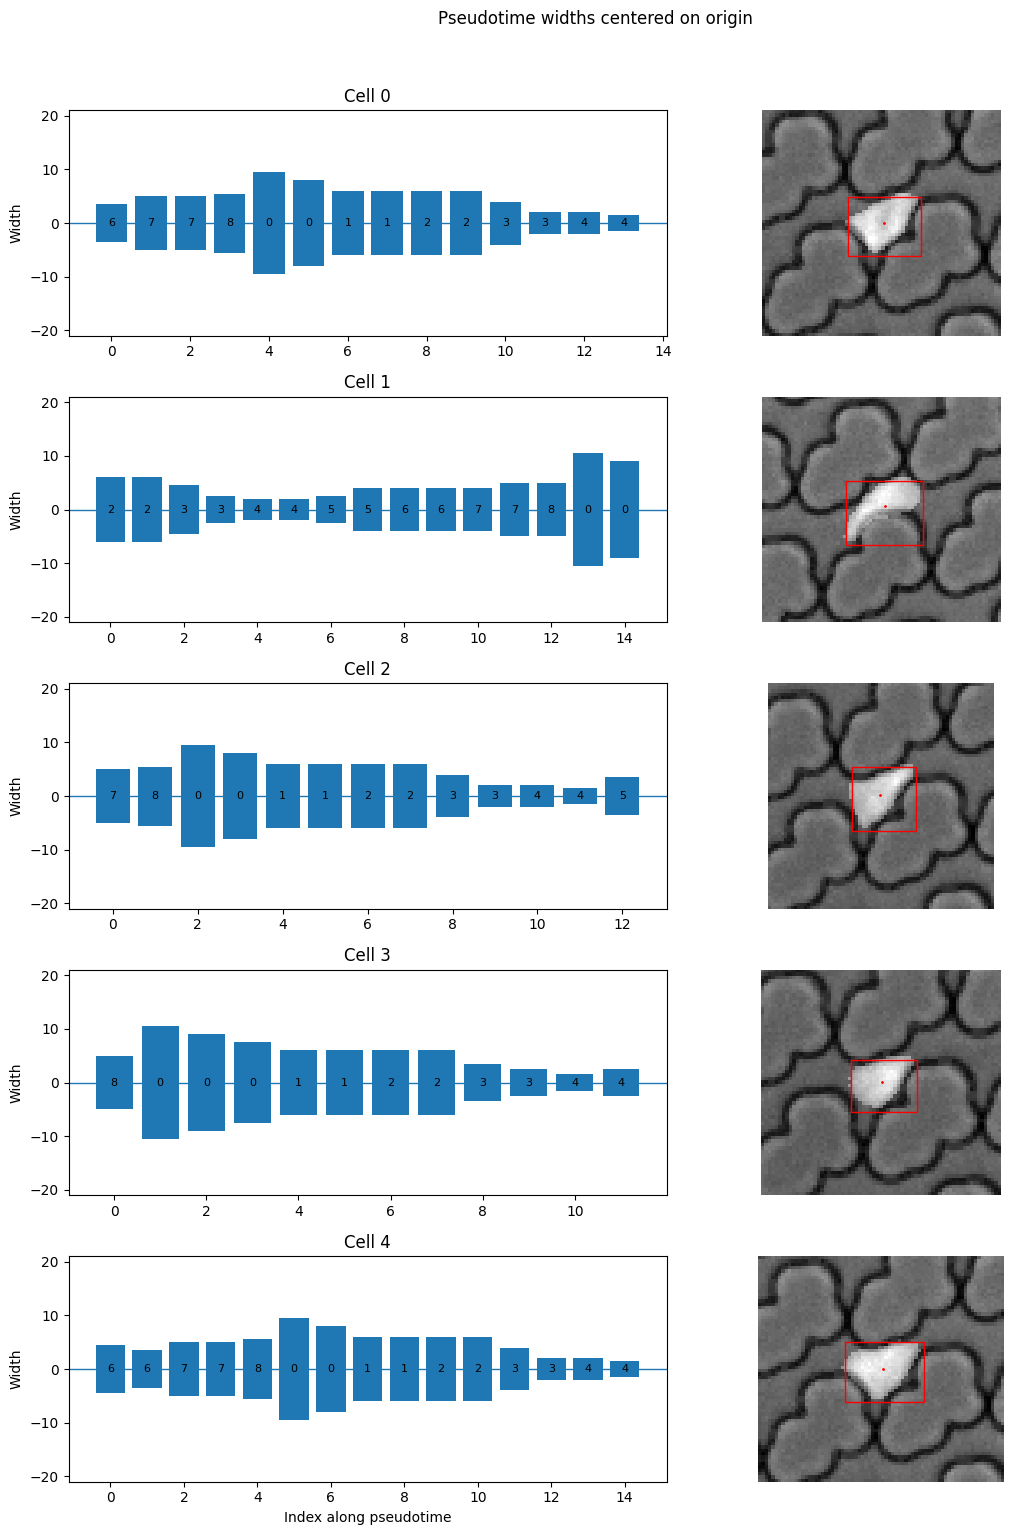

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj6120002_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj4810001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj6850001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj7260001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1476_1_real\separated dapi\obj2590001_stainDAPI.tif


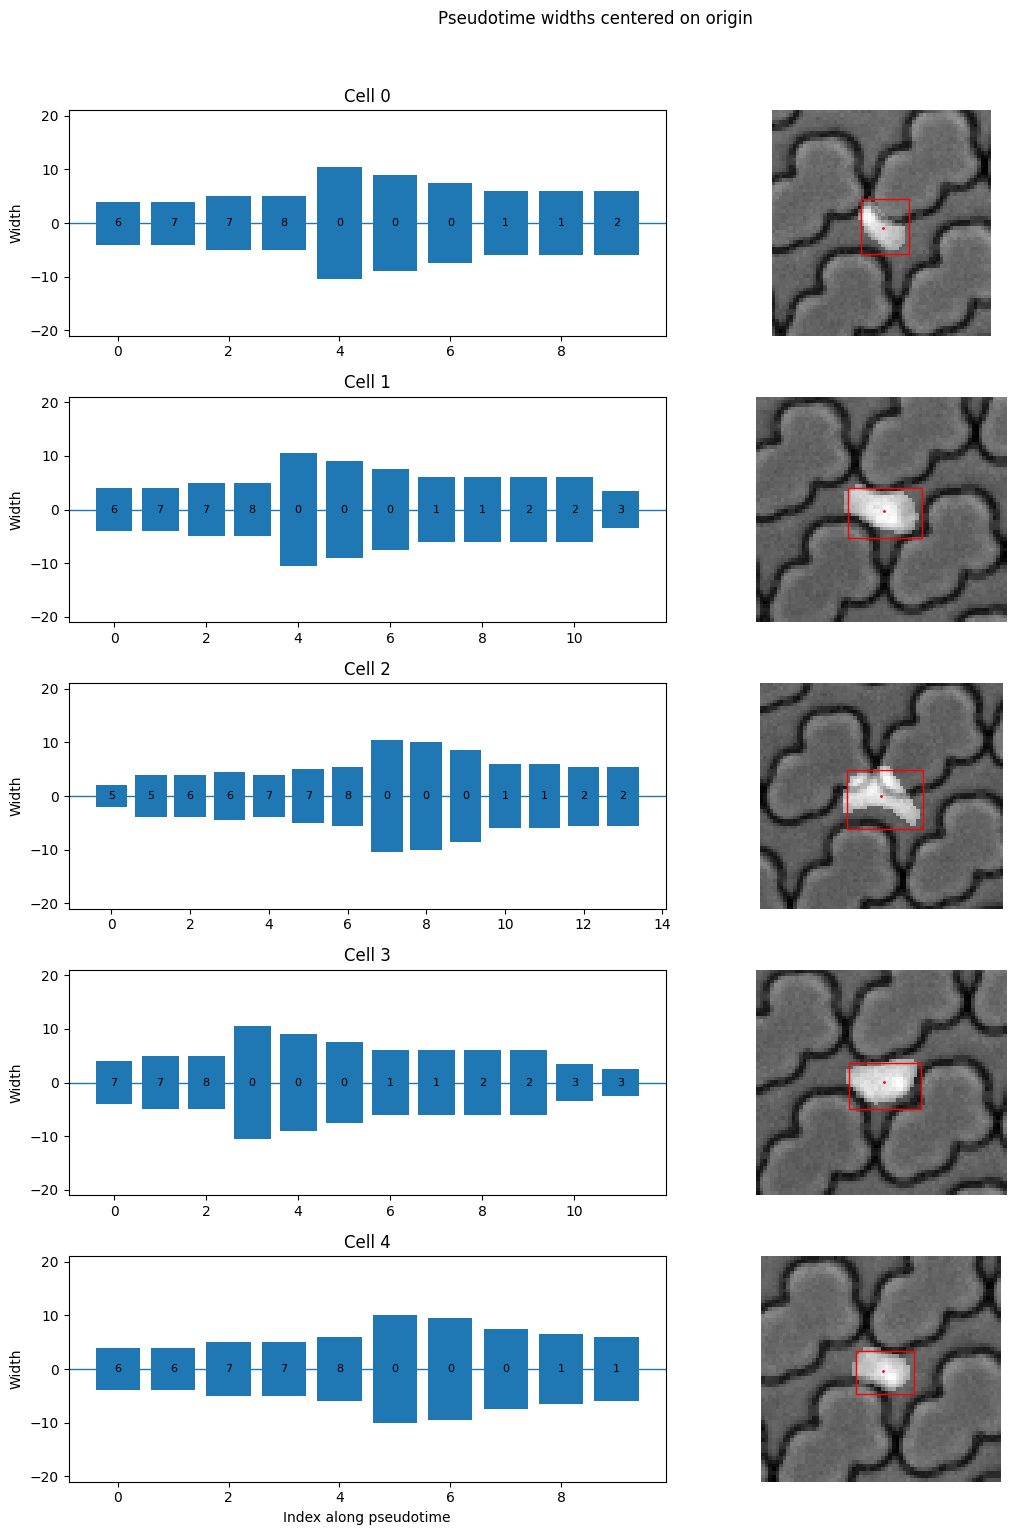

In [88]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 2'), num_cells=5)

<Axes: xlabel='cluster_kmeans'>

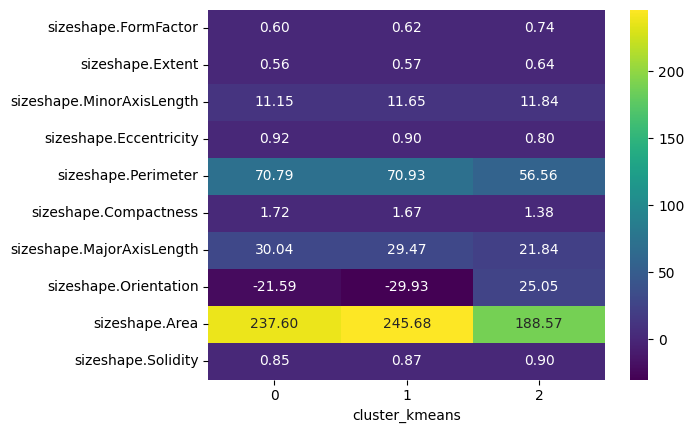

In [89]:
import seaborn as sns

feats = ['AreaShape_FormFactor', 'AreaShape_Extent','AreaShape_MinorAxisLength',
         'AreaShape_Eccentricity',  'AreaShape_Perimeter', 'AreaShape_Compactness', 
         'AreaShape_MajorAxisLength', 'AreaShape_Orientation',
         'AreaShape_Area','AreaShape_Solidity',
        ]

def name_in_df(feat):
    return  'sizeshape.' + feat.split('_')[1]

feats_CPmeasure = []
for feat in feats:
    col = name_in_df(feat)
    if col in SD_clean.columns:
        feats_CPmeasure.append(col)
    else:
        print(f"Feature {name_in_df(feat)} not found in dataframe")


SD_clean[feats_CPmeasure + ['cluster_kmeans']].groupby('cluster_kmeans').mean()

sns.heatmap( SD_clean[feats_CPmeasure + ['cluster_kmeans']] .groupby('cluster_kmeans') .mean() .T, cmap="viridis", annot=True, fmt=".2f" )

<Axes: xlabel='cluster_kmeans'>

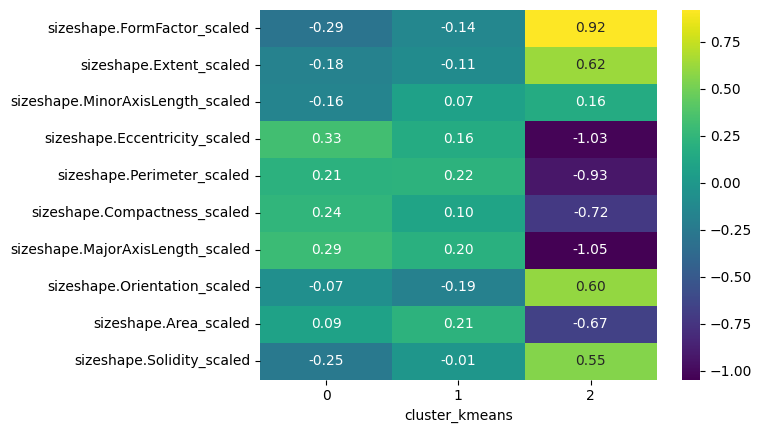

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean[feats_CPmeasure])

feats_CPmeasure_scaled = [f + "_scaled" for f in feats_CPmeasure]

SD_clean[feats_CPmeasure_scaled] = scaled



sns.heatmap(
    SD_clean[feats_CPmeasure_scaled + ['cluster_kmeans']]
    .groupby('cluster_kmeans')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

#Is cluster 3 an outlier cluster with very small cells?

0 0.2796698049180312
1 0.36729944747030996
2 0.3282056803882501


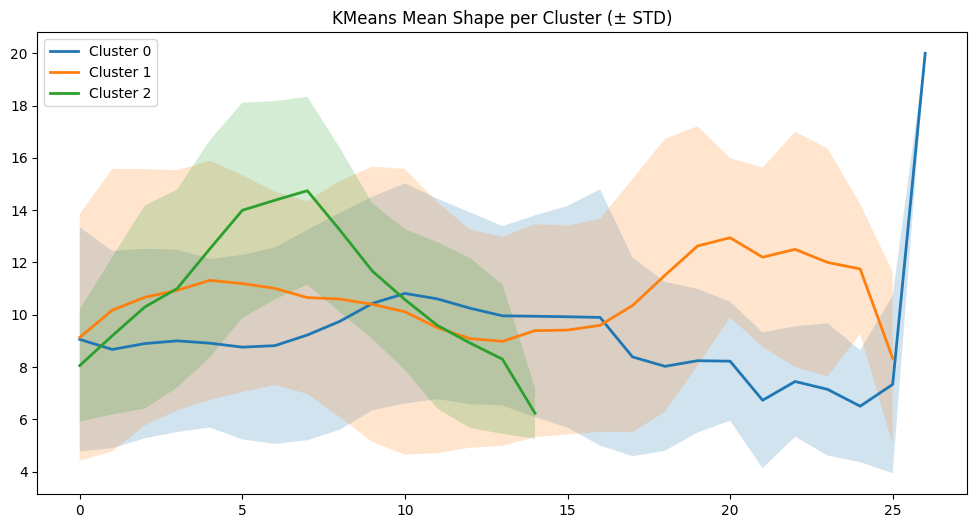

In [91]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(X_scaled, labels_kmeans)
for k in np.unique(labels_kmeans):
    print(k, s[labels_kmeans == k].mean())

X_kmeans = SD_clean["pseudotime_widths"].to_list()
labels_kmeans = SD_clean["cluster_kmeans"].values

plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [92]:
mask = labels_kmeans != 2
features_no_outliers = features[mask]
X_scaled_no_Outliers = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)
labels_clean = kmeans.fit_predict(X_scaled_no_Outliers)
    
s_clean = silhouette_samples(X_scaled_no_Outliers, labels_clean)

for k in np.unique(labels_clean):
    print(k, s_clean[labels_clean == k].mean())


0 0.34491124675233253
1 0.26591789666281956


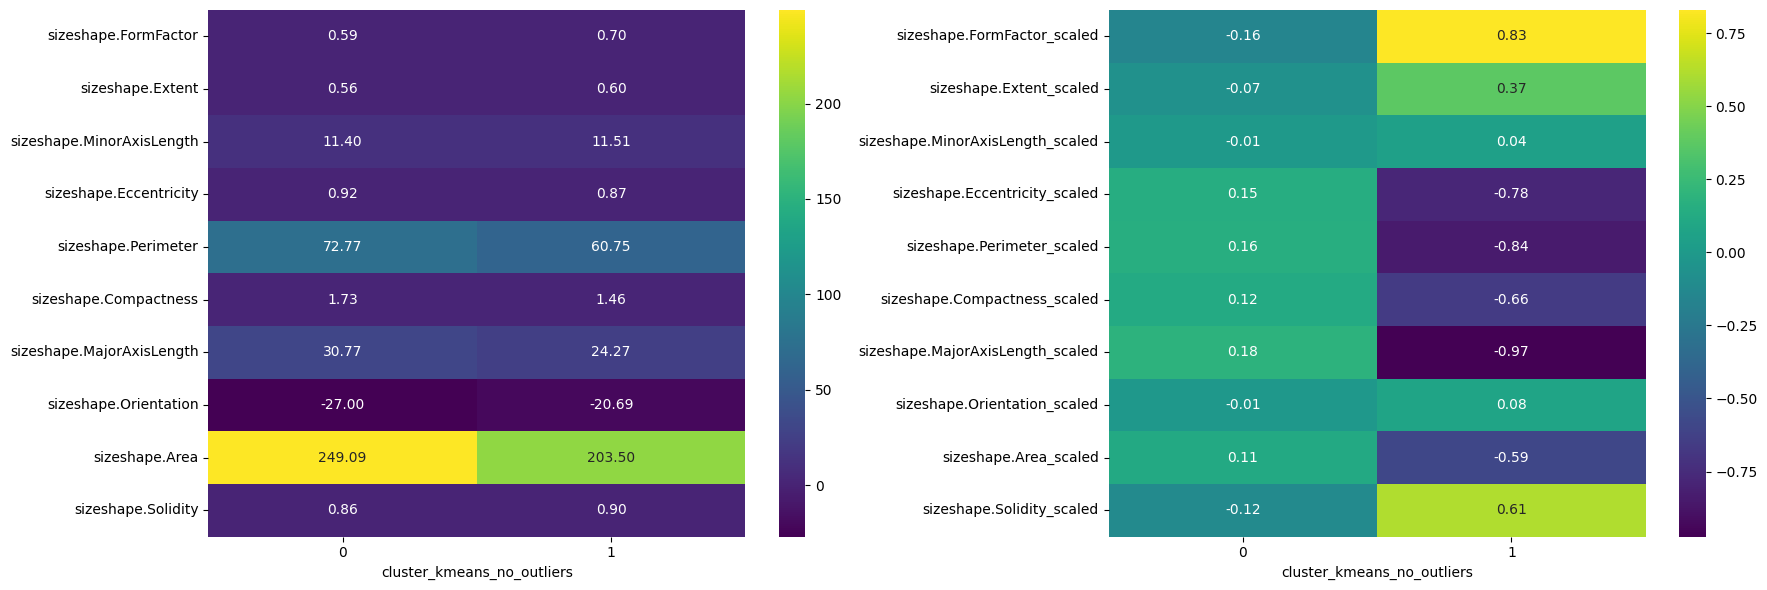

In [112]:
SD_clean_no_outliers = SD_clean.copy()
SD_clean_no_outliers['cluster_kmeans_no_outliers'] = np.where(mask, labels_clean, -1)
SD_clean_no_outliers = SD_clean_no_outliers[SD_clean_no_outliers['cluster_kmeans_no_outliers'] != -1]

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean_no_outliers[feats_CPmeasure])

SD_clean_no_outliers[feats_CPmeasure]
SD_clean_no_outliers[feats_CPmeasure_scaled] = scaled

fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    ax=axes[0]
)

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure_scaled + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    ax=axes[1]
)

plt.tight_layout()

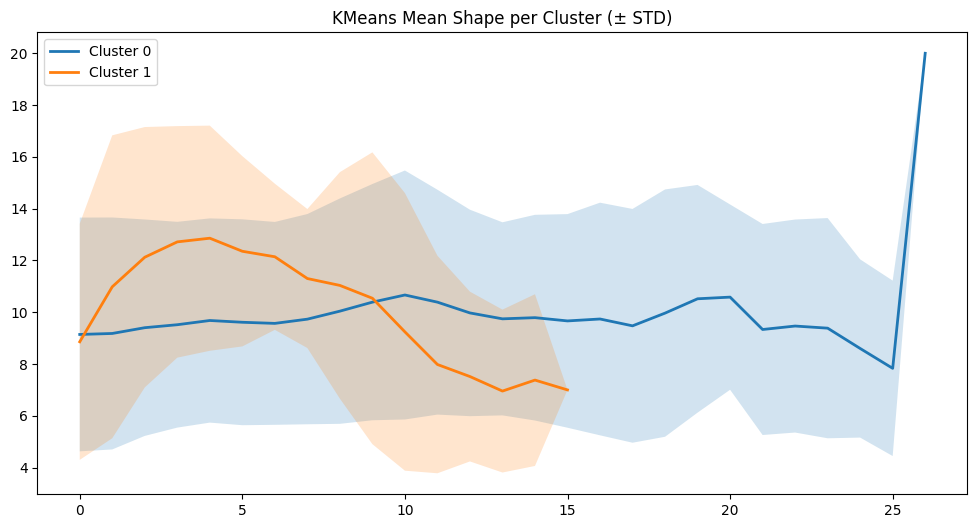

In [94]:
X_kmeans = SD_clean_no_outliers["pseudotime_widths"].to_list()
labels_kmeans = SD_clean_no_outliers["cluster_kmeans_no_outliers"].values



plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2) Optional: PCA to remove collinearity/noise
pca = PCA(n_components=2)  # or more components if needed
X_pca = pca.fit_transform(X_scaled)

# 3) Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X_pca)

# 4) Cluster labels (hard assignment)
labels_gmm = gmm.predict(X_pca)

# 5) Membership probabilities (soft assignment)
probs = gmm.predict_proba(X_pca)   # shape: (n_samples, 3)

# 6) Evaluate quality
sil = silhouette_score(X_pca, labels_gmm)
print("Silhouette GMM:", sil)

Silhouette GMM: 0.15497047927600874


In [96]:
import hdbscan

X = SD_clean['pseudotime_widths'].to_list()

X = [ts for ts in X if len(ts) >= n]  # filter out short series

X = [(ts - np.mean(ts)) / np.std(ts) for ts in X] # z-score normalization

D_dtw = cdist_dtw(X)


In [97]:
import umap
lengths = np.array([len(ts) for ts in X])
L = np.abs(lengths[:, None] - lengths[None, :])

alpha = 0.3  # controls importance of length
D = D_dtw + alpha * L

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric='euclidean'
)

mapper = umap.UMAP(
    metric="precomputed",
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = mapper.fit_transform(D_dtw)

labels_hdb = clusterer.fit_predict(X_umap)  # -1 = noise

unique, counts = np.unique(labels_hdb, return_counts=True)
print(dict(zip(unique, counts)))

c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{np.int64(-1): np.int64(86), np.int64(0): np.int64(37), np.int64(1): np.int64(84), np.int64(2): np.int64(138), np.int64(3): np.int64(181), np.int64(4): np.int64(40), np.int64(5): np.int64(158), np.int64(6): np.int64(48), np.int64(7): np.int64(106)}


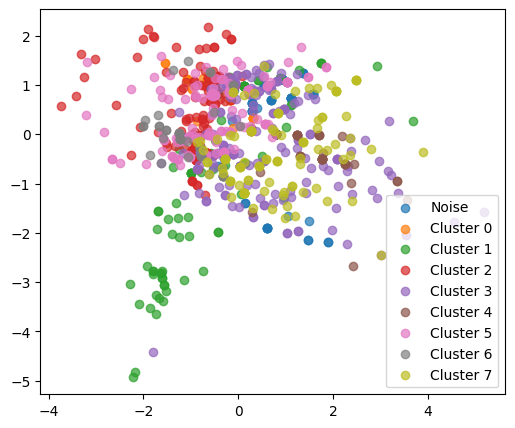

In [98]:
plt.figure(figsize=(6,5))
for c in np.unique(labels_hdb):
    idx = labels_hdb == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.legend()
plt.show()

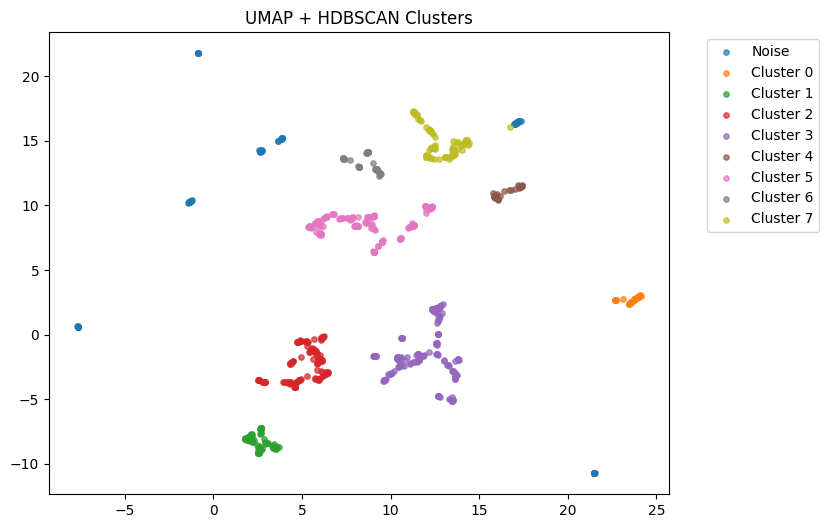

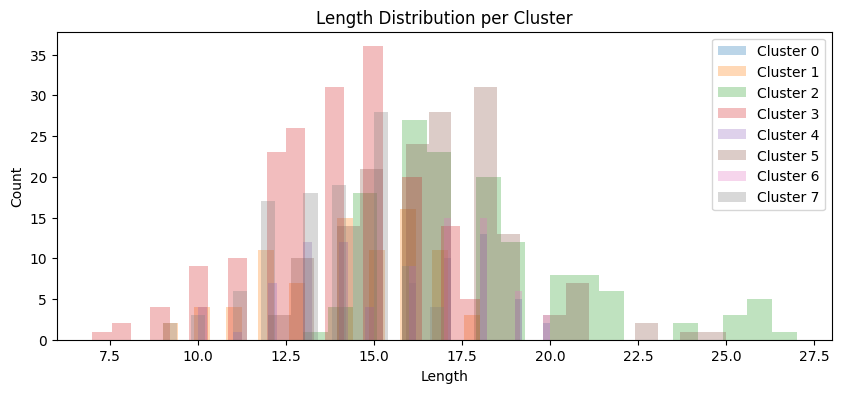

In [99]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels_hdb)

for lab in unique_labels:
    idx = labels_hdb == lab
    label = "Noise" if lab == -1 else f"Cluster {lab}"
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], s=15, alpha=0.7, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

def plot_length_distribution(X, labels):
    lengths = np.array([len(ts) for ts in X])

    plt.figure(figsize=(10,4))
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        idx = labels == lab
        plt.hist(lengths[idx], bins=20, alpha=0.3, label=f"Cluster {lab}")

    plt.legend()
    plt.title("Length Distribution per Cluster")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()

plot_length_distribution(X, labels_hdb)

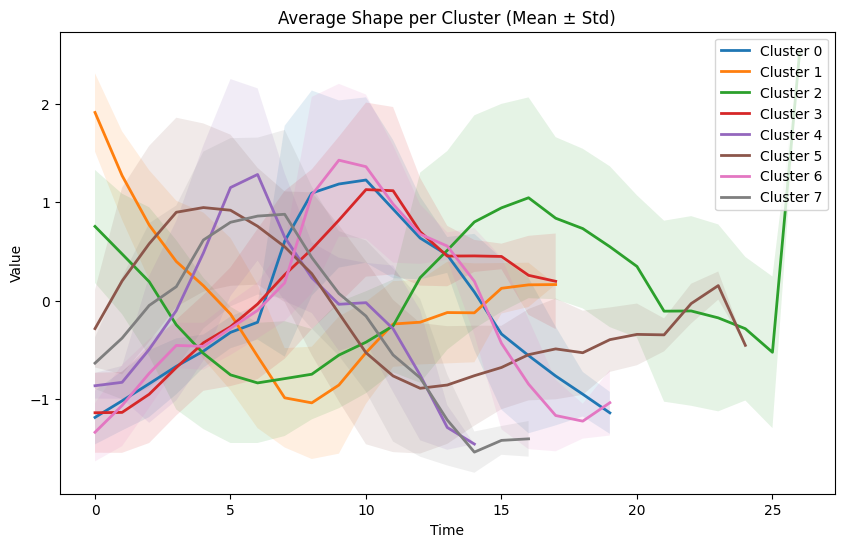

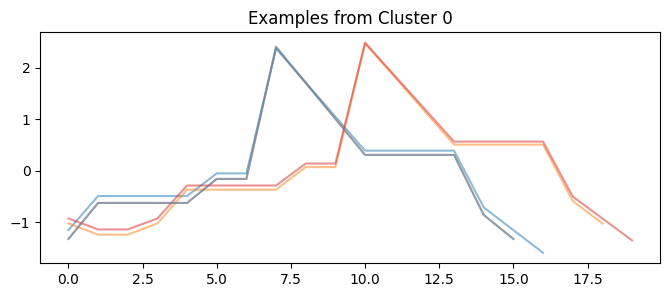

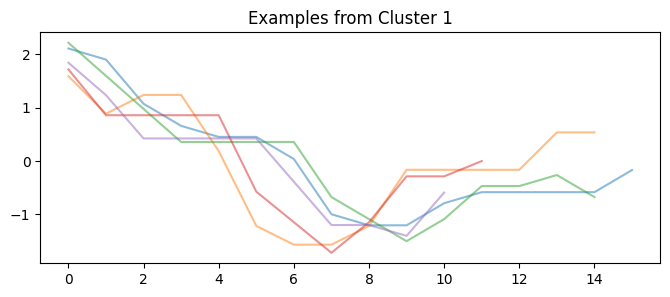

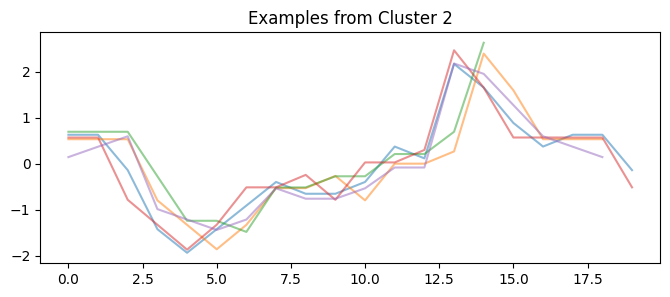

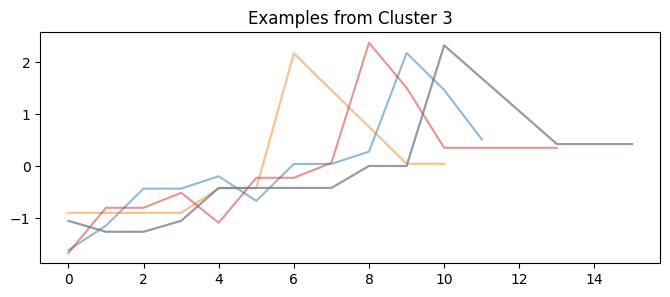

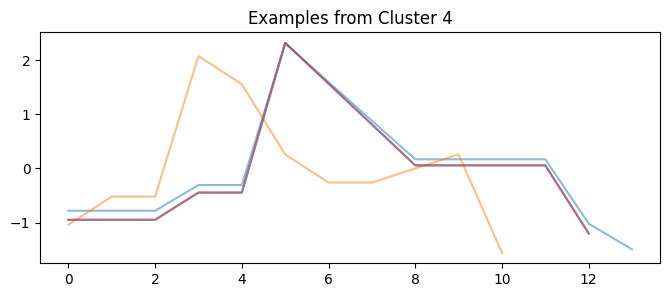

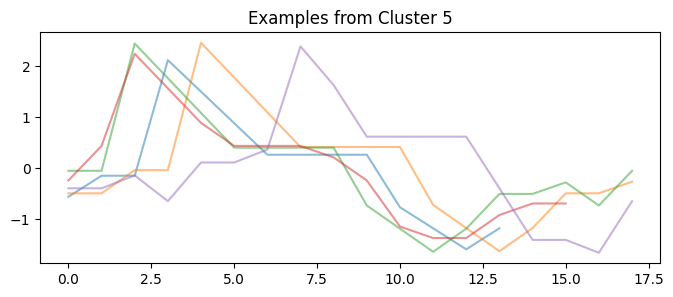

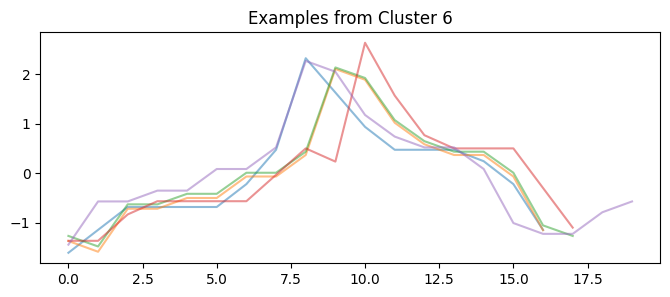

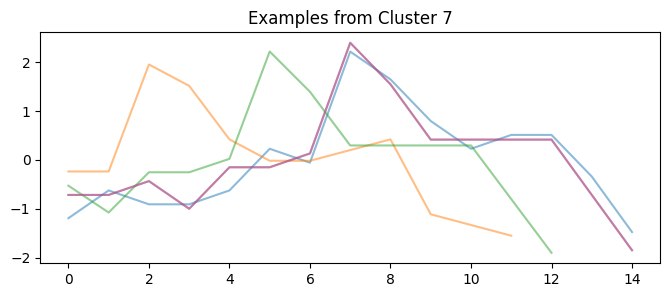

In [100]:
plt.figure(figsize=(10, 6))

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue

    idx = labels_hdb == lab
    cluster_ts = [np.asarray(X[i], dtype=float) for i in np.where(idx)[0]]

    # Pad all sequences to the max length
    max_len = max(len(ts) for ts in cluster_ts)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), 'constant', constant_values=np.nan)
        for ts in cluster_ts
    ]
    aligned = np.vstack(aligned)

    # Mean and STD
    mean_ts = np.nanmean(aligned, axis=0)
    std_ts  = np.nanstd(aligned, axis=0)

    t = np.arange(max_len)

    # Plot mean
    plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)

    # Plot STD as shaded area
    plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.12)

plt.legend()
plt.title("Average Shape per Cluster (Mean ± Std)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

import random

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue
    
    idx = np.where(labels_hdb == lab)[0]
    sample_idxs = random.sample(list(idx), min(5, len(idx)))

    plt.figure(figsize=(8, 3))
    for i in sample_idxs:
        plt.plot(X[i], alpha=0.5)
    plt.title(f"Examples from Cluster {lab}")
    plt.show()

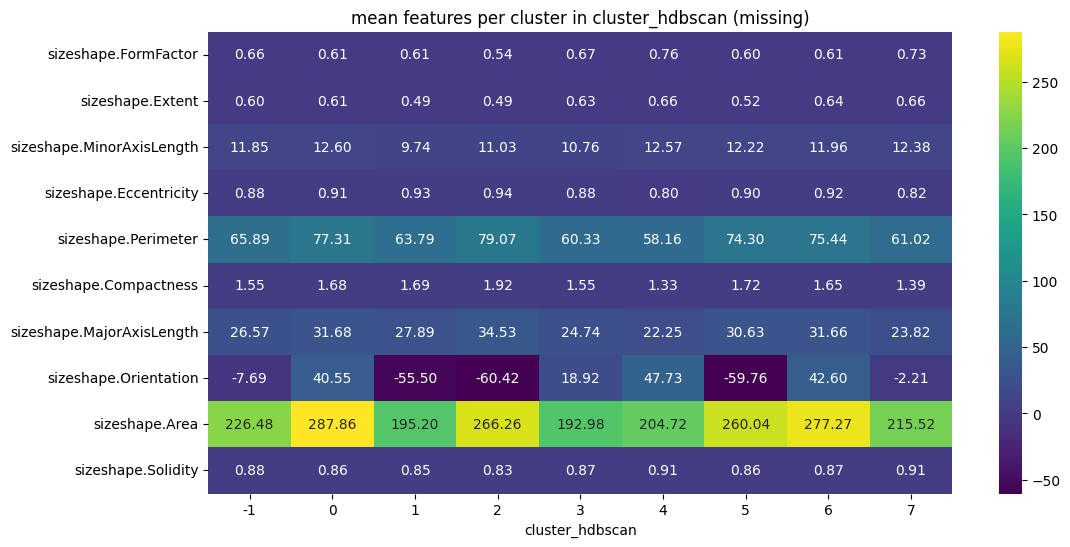

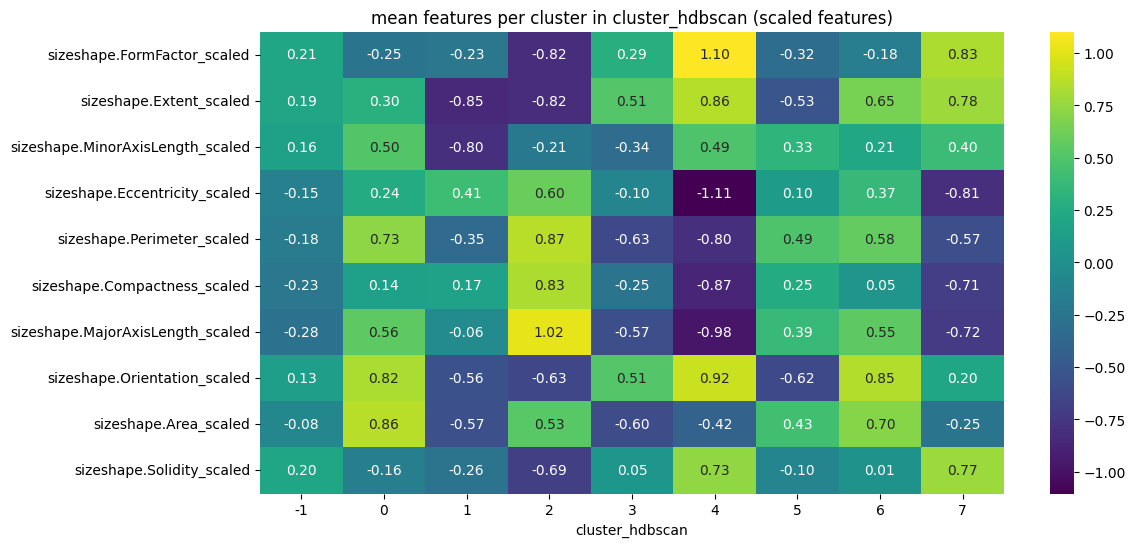

In [101]:
SD_clean["cluster_hdbscan"] = labels_hdb

def plot_metadata_heatmap(df, features, cluster_col, title="missing"):
    plt.figure(figsize=(12,6))
    sns.heatmap(
        df[features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T,
        cmap="viridis",
        annot=True,
        fmt=".2f",
    )
    plt.title(f"mean features per cluster in {cluster_col} ({title})")
    plt.show()




plot_metadata_heatmap(
    SD_clean,
    feats_CPmeasure,                # your list of metadata/morphology features
    "cluster_hdbscan"
)

plot_metadata_heatmap(
    SD_clean,
    feats_CPmeasure_scaled,         # your list of metadata/morphology features
    "cluster_hdbscan",
    title="scaled features"
)

In [107]:
import os
import shutil
from tqdm import tqdm

def export_dapi_by_cluster(df, cluster_col, dapi_col, out_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    dapi_col    : column name containing the DAPI file paths (e.g. 'path_dapi')
    out_dir     : output directory where cluster folders will be created
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            src = row[dapi_col]
            
            if not os.path.exists(src):
                print(f"WARNING: File not found: {src}")
                continue

            # keep original filename
            filename = os.path.basename(src)
            dst = os.path.join(cluster_path, filename)

            shutil.copy(src, dst)

    print("Done.")

export_dapi_by_cluster(
    df=SD_clean,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    dapi_col="path_dapi",
    out_dir="sorted_dapi_images_UMAP+HDBSCAN_1476"     # will be created automatically
)

Exporting 86 DAPI images for cluster -1...


100%|██████████| 86/86 [00:00<00:00, 1101.57it/s]


Exporting 37 DAPI images for cluster 0...


100%|██████████| 37/37 [00:00<00:00, 1026.85it/s]


Exporting 84 DAPI images for cluster 1...


100%|██████████| 84/84 [00:00<00:00, 1049.04it/s]


Exporting 138 DAPI images for cluster 2...


100%|██████████| 138/138 [00:00<00:00, 1028.92it/s]


Exporting 181 DAPI images for cluster 3...


100%|██████████| 181/181 [00:00<00:00, 803.71it/s] 


Exporting 40 DAPI images for cluster 4...


100%|██████████| 40/40 [00:00<00:00, 1051.67it/s]


Exporting 158 DAPI images for cluster 5...


100%|██████████| 158/158 [00:00<00:00, 1011.90it/s]


Exporting 48 DAPI images for cluster 6...


100%|██████████| 48/48 [00:00<00:00, 1020.35it/s]


Exporting 106 DAPI images for cluster 7...


100%|██████████| 106/106 [00:00<00:00, 847.24it/s]

Done.


In [109]:

df_identifyPrimaryObjects = pd.read_csv("datasets/1476/MyExpt_IdentifyPrimaryObjects.csv")
df_Phalloidin_segmented = pd.read_csv("datasets/MyExpt_Phalloidin_segmented.csv")
df_YAP_segmented = pd.read_csv("datasets/MyExpt_YAP_segmented.csv")

SD_clean["ImageNumber"] = SD_clean.index // 10000
SD_clean["ObjectNumber"] = SD_clean.index % 10000

colums = ['ObjectNumber', 'Metadata_ObjNumber'] + feats

cluster_map = SD_clean[["ImageNumber", "ObjectNumber", "cluster_hdbscan"]]

def add_cluster_to_cp(cp_df, cluster_map):
    return cp_df.merge(
        cluster_map,
        left_on=["Metadata_ObjNumber", "ObjectNumber"],
        right_on=["ImageNumber", "ObjectNumber"],
        how="left"
    )  # avoid duplicate

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map)

df_identifyPrimaryObjects["cluster_hdbscan"]



0      6.0
1      3.0
2      3.0
3      1.0
4      3.0
      ... 
735    5.0
736    3.0
737    3.0
738    1.0
739   -1.0
Name: cluster_hdbscan, Length: 740, dtype: float64

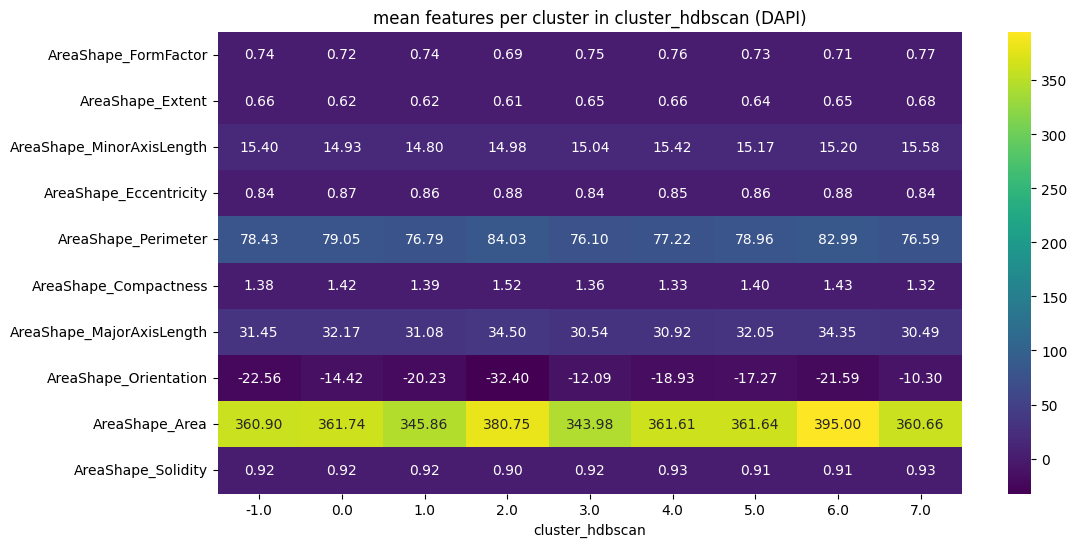

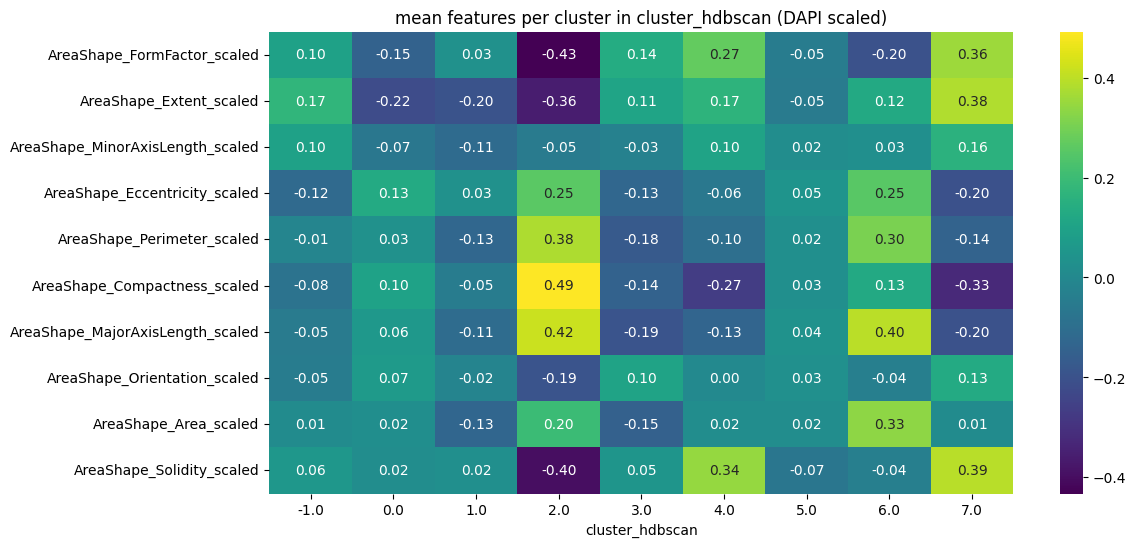

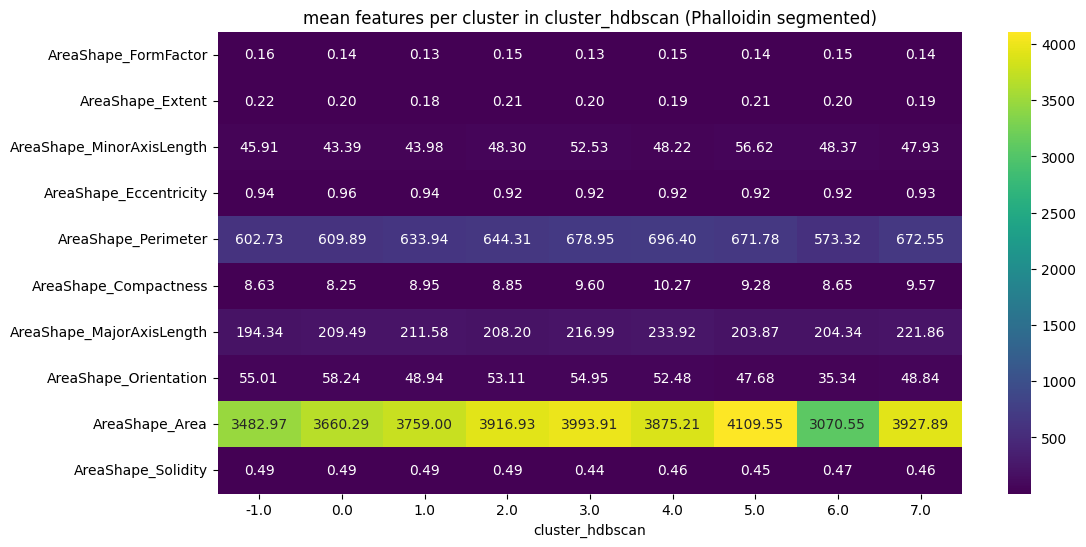

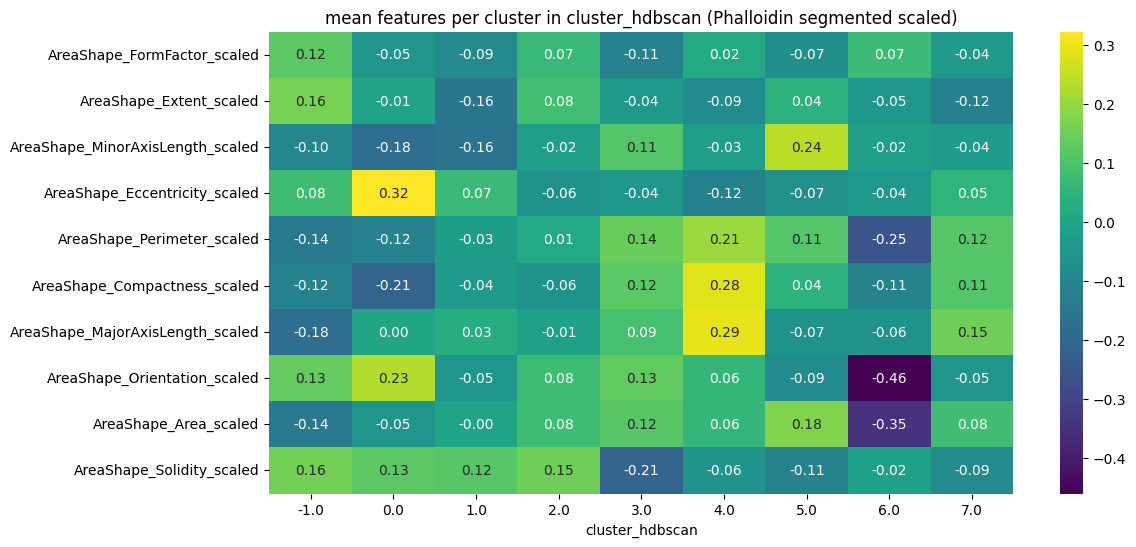

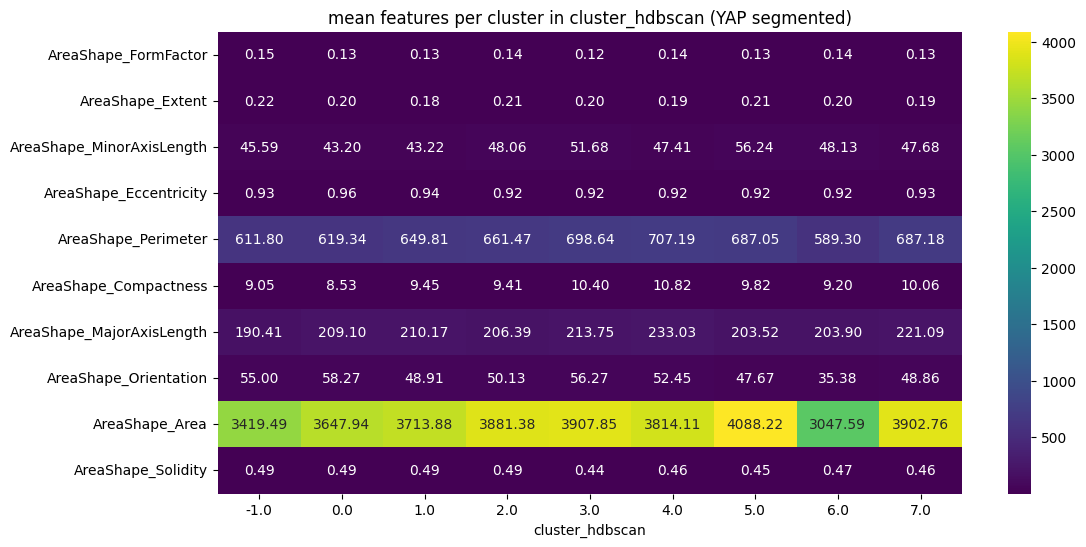

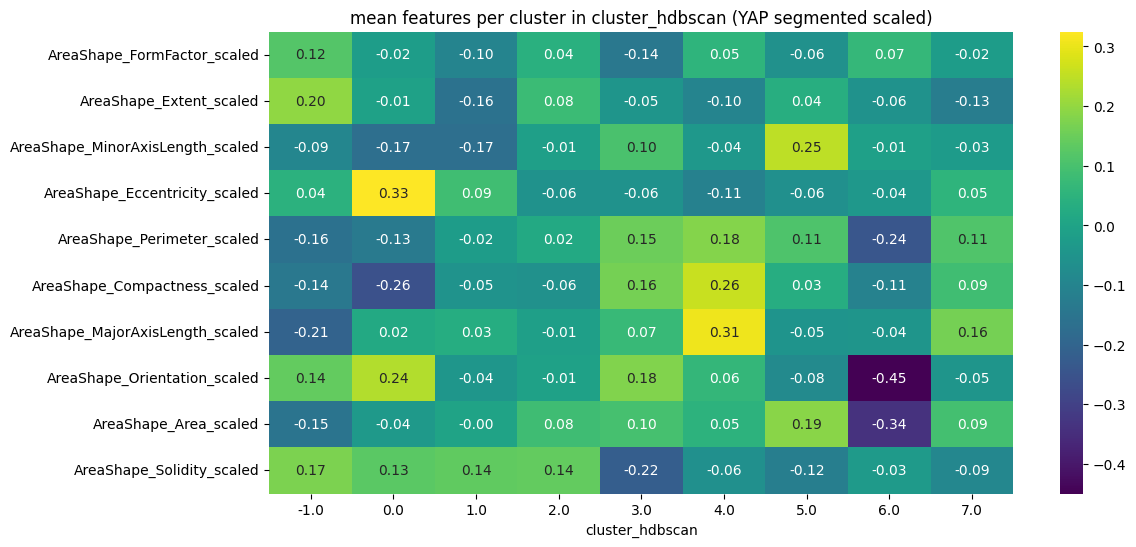

DAPI cluster counts:
cluster_hdbscan
 3.0    132
 5.0    116
 2.0    106
 7.0     79
-1.0     69
 1.0     65
 6.0     42
 4.0     31
 0.0     27
Name: count, dtype: int64

Phalloidin segmented cluster counts:
cluster_hdbscan
 3.0    79
 5.0    64
 2.0    58
 7.0    54
 1.0    41
-1.0    39
 6.0    22
 4.0    19
 0.0    17
Name: count, dtype: int64

YAP segmented cluster counts:
cluster_hdbscan
 3.0    79
 5.0    64
 2.0    58
 7.0    54
 1.0    41
-1.0    39
 6.0    22
 4.0    19
 0.0    17
Name: count, dtype: int64


In [110]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_identifyPrimaryObjects[feats])

feats_scaled = [f + "_scaled" for f in feats]

CP_DAPI = df_identifyPrimaryObjects.copy()
CP_DAPI[feats_scaled] = scaled



plot_metadata_heatmap(
    CP_DAPI,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="DAPI"
)

plot_metadata_heatmap(
    CP_DAPI,
    feats_scaled,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="DAPI scaled"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_Phalloidin_segmented[feats])

CP_ACTIN = df_Phalloidin_segmented.copy()
CP_ACTIN[feats_scaled] = scaled

plot_metadata_heatmap(
    CP_ACTIN,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="Phalloidin segmented"
)

plot_metadata_heatmap(
    CP_ACTIN,
    feats_scaled,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="Phalloidin segmented scaled"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_YAP_segmented[feats])

CP_YAP = df_YAP_segmented.copy()
CP_YAP[feats_scaled] = scaled

plot_metadata_heatmap(
    CP_YAP,
    feats,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="YAP segmented"
)

plot_metadata_heatmap(
    CP_YAP,
    feats_scaled,                # your list of metadata/morphology features
    "cluster_hdbscan",
    title="YAP segmented scaled"
)


#counts per cluster
print("DAPI cluster counts:")
print(df_identifyPrimaryObjects["cluster_hdbscan"].value_counts())
print("\nPhalloidin segmented cluster counts:")
print(df_Phalloidin_segmented["cluster_hdbscan"].value_counts())
print("\nYAP segmented cluster counts:")
print(df_YAP_segmented["cluster_hdbscan"].value_counts())

In [111]:


def export_dapi_by_cluster(df, cluster_col, imgID_col, out_dir, Actin_dir, YAP_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    imgID_col   : column name containing the image IDs (e.g. 'imgID')
    out_dir     : output directory where cluster folders will be created
    Actin_dir   : directory containing Actin images
    YAP_dir     : directory containing YAP images
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            img_id = row[imgID_col]
            img_prefix = f"obj{img_id:04d}"

            # --- find matching Actin file ---
            actin_matches = [
                f for f in os.listdir(Actin_dir)
                if f.startswith(img_prefix)
            ]

            # --- find matching YAP file ---
            yap_matches = [
                f for f in os.listdir(YAP_dir)
                if f.startswith(img_prefix)
            ]

            # copy Actin files
            for f in actin_matches:
                src = os.path.join(Actin_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)

            # copy YAP files
            for f in yap_matches:
                src = os.path.join(YAP_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)


            shutil.copy(src, dst)

    print("Done.")


export_dapi_by_cluster(
    df=df_identifyPrimaryObjects,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    imgID_col="Metadata_ObjNumber",
    out_dir="sorted_YAP+ACTIN_by_cluster_UMAP+HDBSCAN_1476",     # will be created automatically
    Actin_dir="../1476_1/Actin_DAPI_overlays",
    YAP_dir="../1476_1/YAP_DAPI_overlays"
)



     

Exporting 69 DAPI images for cluster -1.0...


100%|██████████| 69/69 [00:00<00:00, 231.63it/s]


Exporting 27 DAPI images for cluster 0.0...


100%|██████████| 27/27 [00:00<00:00, 243.02it/s]


Exporting 65 DAPI images for cluster 1.0...


100%|██████████| 65/65 [00:00<00:00, 230.94it/s]


Exporting 106 DAPI images for cluster 2.0...


100%|██████████| 106/106 [00:00<00:00, 227.26it/s]


Exporting 132 DAPI images for cluster 3.0...


100%|██████████| 132/132 [00:00<00:00, 227.70it/s]


Exporting 31 DAPI images for cluster 4.0...


100%|██████████| 31/31 [00:00<00:00, 243.87it/s]


Exporting 116 DAPI images for cluster 5.0...


100%|██████████| 116/116 [00:00<00:00, 227.43it/s]


Exporting 42 DAPI images for cluster 6.0...


100%|██████████| 42/42 [00:00<00:00, 229.30it/s]


Exporting 79 DAPI images for cluster 7.0...


100%|██████████| 79/79 [00:00<00:00, 234.91it/s]


Exporting 0 DAPI images for cluster nan...


0it [00:00, ?it/s]

Done.
